# Sprint 11 nivell 1

### Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

##### CREO UNA CLASSE PER A CONNECTAR/DESCONNECTAR i FER CONSULTES A LA BBDD DE MYSQL

In [2]:
# CREO UNA CLASSE PER A CONNECTAR / DESCONNECTAR i FER CONSULTES A LA BBDD DE MYSQL 
import mysql.connector

class MySQLConnection:
    def __init__(self, host, user, password, database):
        self.host = host
        self.user = user
        self.password = password
        self.database = database
        self.connection = None

    def connect(self):
        try:
            self.connection = mysql.connector.connect(
                host=self.host,
                user=self.user,
                password=self.password,
                database=self.database
            )
            print("Connection to MySQL Workbench established.")
        except mysql.connector.Error as err:
            print(f"Error: {err}")

    def disconnect(self):
        if self.connection:
            self.connection.close()
            print("Connection to MySQL Workbench closed.")

    def execute_query(self, query):
        cursor = self.connection.cursor()
        cursor.execute(query)
        results = cursor.fetchall()
        cursor.close()
        return results
    


## 1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

##### CREO UNA FUNCIO PER A CARREGAR LES DADES EN UN DICCIONARI ON CADA KEY ES EL NOM DE LA TAULA I EL DATAFRAME EL SEU VALOR

In [3]:
# CREO UNA FUNCIO PER A CARREGAR LES DADES EN UN DICCIONARI



import pandas as pd


def cargar_tablas_en_diccionario(conexion):
    """Carga todas las tablas de la BBDD en un diccionario de DataFrames."""
    if conexion is None or not conexion.is_connected():
        print("No hay conexión activa")
        return None

    cursor = conexion.cursor()
    cursor.execute("SHOW TABLES")
    tablas = cursor.fetchall()

    dataframes = {}

    for (nombre_tabla,) in tablas:
        query = f"SELECT * FROM `{nombre_tabla}`"
        df = pd.read_sql(query, conexion)        
        dataframes[nombre_tabla] = df
        print(f"Tabla '{nombre_tabla}' cargada ({len(df)} filas)")
        #print(dataframes[nombre_tabla])
    cursor.close()
    return dataframes



# FEM LA CONEXIÓ
db = MySQLConnection(host='localhost', user='root', password='lluis1976', database='sprint4')
db.connect()

dicc_df_BBDD = cargar_tablas_en_diccionario(db.connection)

db.disconnect()
# Puedes acceder así:
# df=dicc_df_BBDD["companies"]
# print(df.head(10))
# print(dicc_df_BBDD["companies"].head(10))


Connection to MySQL Workbench established.
Tabla 'companies' cargada (100 filas)
Tabla 'credit_card' cargada (5000 filas)
Tabla 'credit_card_status' cargada (5000 filas)
Tabla 'laptop' cargada (5 filas)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10960\631808115.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


Tabla 'maximosminimosamoutxusuario' cargada (5000 filas)
Tabla 'products' cargada (100 filas)
Tabla 'theatersnew' cargada (1564 filas)
Tabla 'transaction_products' cargada (253391 filas)
Tabla 'transactions' cargada (100000 filas)
Tabla 'transactionsproductsuserscompanies' cargada (253391 filas)
Tabla 'users' cargada (5000 filas)
Connection to MySQL Workbench closed.


#### CREO UNA FUNCIO PER CREAR UNA DATAFRAME INDEPENT PER CADA TAULA USANT LA FUNCIO GLOBALS()

In [4]:
def cargar_tablas_como_dataframes(conexion):
    """
    Crea un DataFrame independiente por cada tabla de la base de datos.
    El nombre del DataFrame será igual al nombre de la tabla.
    """
    if conexion is None or not conexion.is_connected():
        print("No hay conexión activa")
        return

    cursor = conexion.cursor()
    cursor.execute("SHOW TABLES")
    tablas = cursor.fetchall()

    for (nombre_tabla,) in tablas:
        query = f"SELECT * FROM `{nombre_tabla}`"
        df = pd.read_sql(query, conexion)
        globals()[nombre_tabla] = df  # Crea variable global con el nombre de la tabla
        print(f"DataFrame '{nombre_tabla}' creado con {len(df)} filas")
        print(nombre_tabla)

    cursor.close()

# FEM LA CONEXIÓ
db = MySQLConnection(host='localhost', user='root', password='lluis1976', database='sprint4')
db.connect()

cargar_tablas_como_dataframes(db.connection)

db.disconnect()

#print(products.head(10))

Connection to MySQL Workbench established.
DataFrame 'companies' creado con 100 filas
companies
DataFrame 'credit_card' creado con 5000 filas
credit_card
DataFrame 'credit_card_status' creado con 5000 filas
credit_card_status
DataFrame 'laptop' creado con 5 filas
laptop


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10960\4282416640.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


DataFrame 'maximosminimosamoutxusuario' creado con 5000 filas
maximosminimosamoutxusuario
DataFrame 'products' creado con 100 filas
products
DataFrame 'theatersnew' creado con 1564 filas
theatersnew
DataFrame 'transaction_products' creado con 253391 filas
transaction_products
DataFrame 'transactions' creado con 100000 filas
transactions
DataFrame 'transactionsproductsuserscompanies' creado con 253391 filas
transactionsproductsuserscompanies
DataFrame 'users' creado con 5000 filas
users
Connection to MySQL Workbench closed.


## 2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

__Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.__

- Una variable numèrica.
- Dues variables numèriques.
- Una variable categòrica.
- Una variable categòrica i una numèrica.
- Dues variables categòriques.
- Tres variables combinades.
- Crea un Pairplot.

### - Una variable numèrica

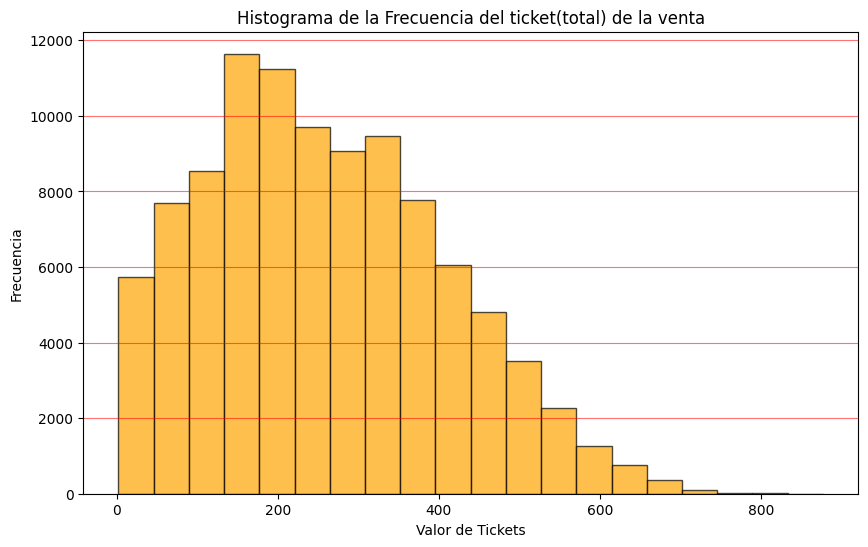

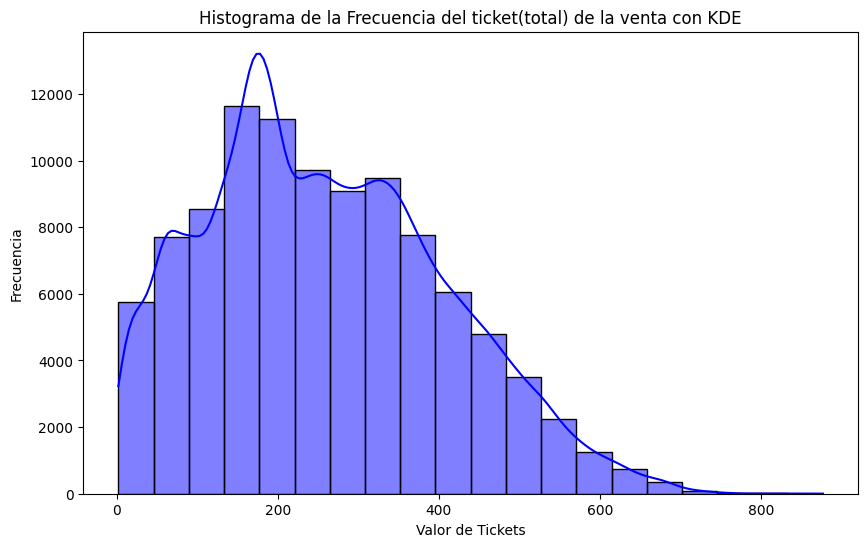

In [5]:
import matplotlib.pyplot as plt

import seaborn as sns

media_ventas=dicc_df_BBDD["transactions"]["amount"] #origen diccinaro_df

plt.figure(figsize=(10,6))
plt.hist(media_ventas,bins=20,alpha=0.7,  color='orange', edgecolor='black')
plt.title('Histograma de la Frecuencia del ticket(total) de la venta')
plt.xlabel('Valor de Tickets')
plt.ylabel('Frecuencia')
plt.grid(axis="y",color="red", alpha=0.55)
plt.show()



media_ventas2=transactions["amount"] # origen variable global df

plt.figure(figsize=(10, 6))
sns.histplot(media_ventas2, bins=20, kde=True, color='blue')
plt.title('Histograma de la Frecuencia del ticket(total) de la venta con KDE')
plt.xlabel('Valor de Tickets')
plt.ylabel('Frecuencia')
plt.show()

### - Dues variables numèriques.

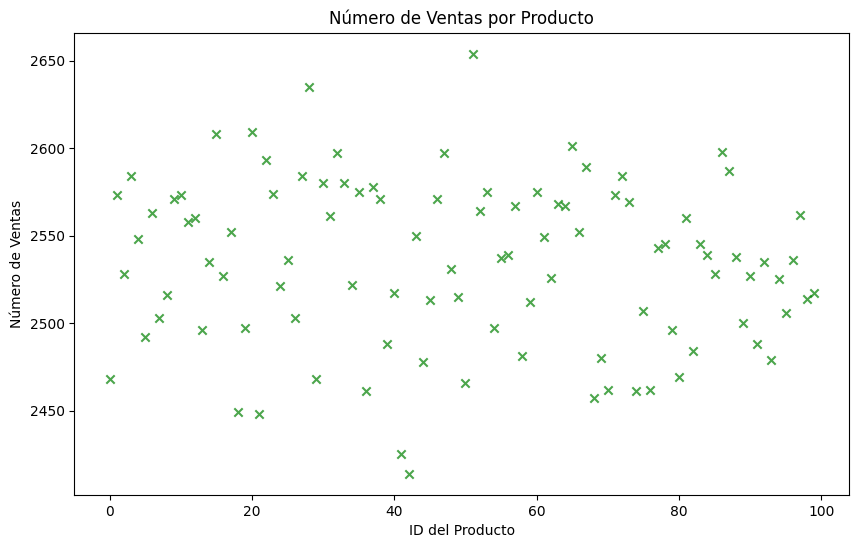

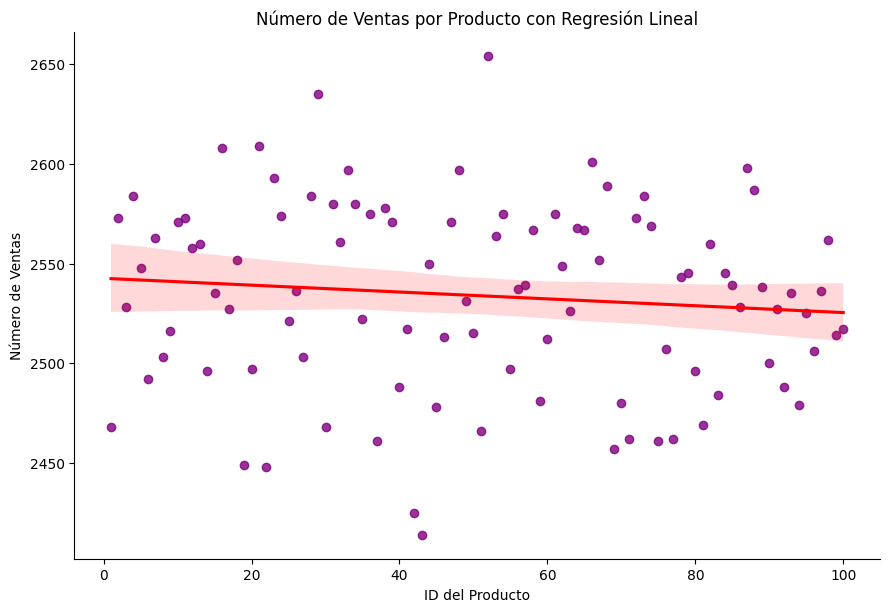

In [6]:
nro_praduct_sell = dicc_df_BBDD["transaction_products"].groupby("product_id").count().reset_index()

#nro_praduct_sell=nro_praduct_sell.unstack() # origen diccionario_df
#print(nro_praduct_sell)
plt.figure(figsize=(10,6))
plt.scatter(nro_praduct_sell.index, nro_praduct_sell["transaction_id"], alpha=0.7, color='green', marker='x')
plt.title('Número de Ventas por Producto')
plt.xlabel('ID del Producto')
plt.ylabel('Número de Ventas')
plt.show()


nro_praduct_sell2 = transaction_products.groupby("product_id").count().reset_index() # origen variable global df
#print(nro_praduct_sell2)
# Usamos lmplot referenciando las columnas por nombre
sns.lmplot(data=nro_praduct_sell2, x='product_id', y='transaction_id',
				 height=6, aspect=1.5, 
				scatter_kws={'color':'purple'}, line_kws={'color':'red'})
plt.title('Número de Ventas por Producto con Regresión Lineal')
plt.xlabel('ID del Producto')   
plt.ylabel('Número de Ventas')
plt.show()

### - Una variable categòrica.

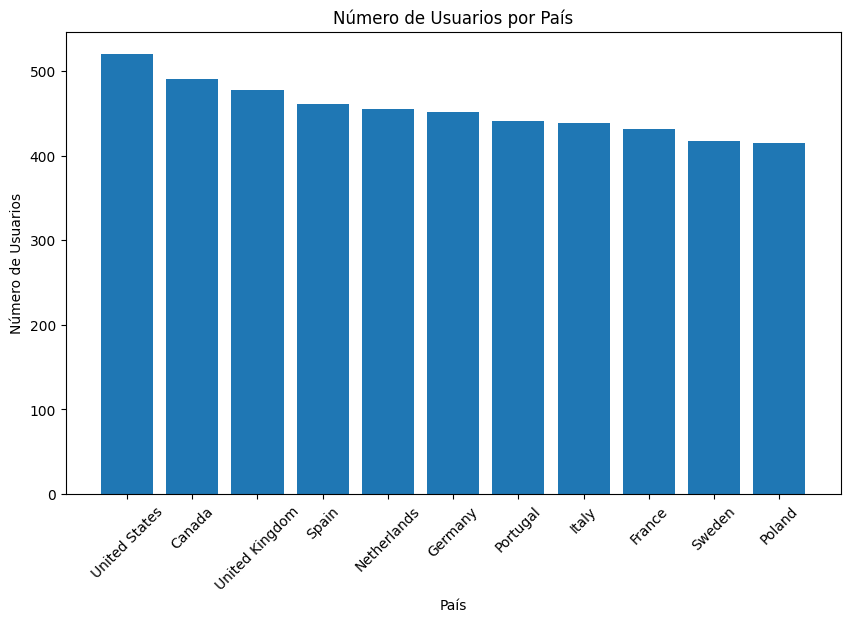

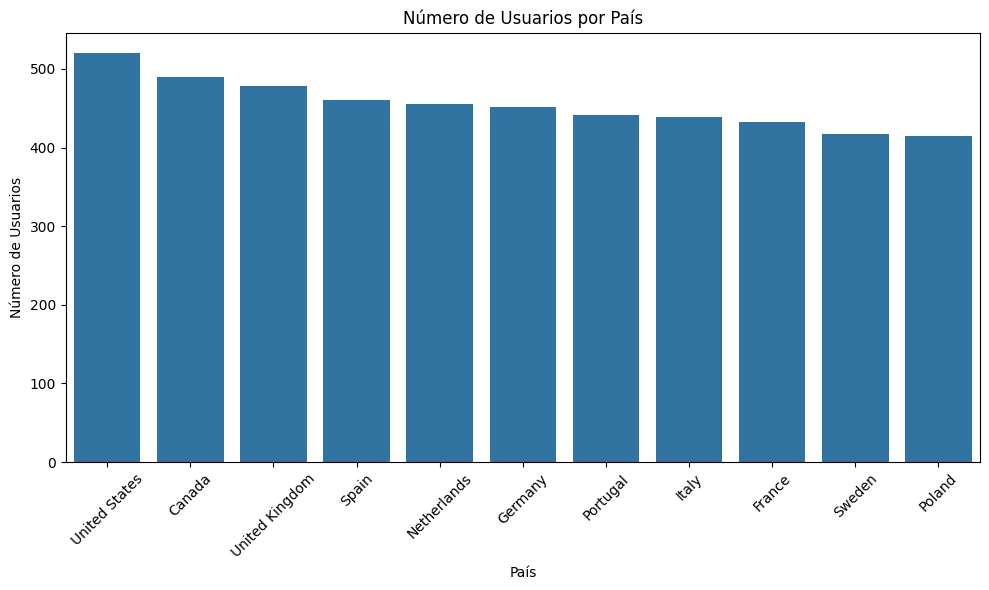

In [7]:
pais = dicc_df_BBDD["users"]["country"].value_counts().reset_index()  # origen diccionario_df
#pais = users['country'].value_counts()  # origen variable global 
pais = pais.sort_values(by='count', ascending=False)
#print(pais)
plt.figure(figsize=(10,6))
#pais.plot.bar(color='lightblue',rot=45)
plt.bar(pais['country'], pais['count'])
plt.title('Número de Usuarios por País')    
plt.xlabel('País')
plt.xticks(rotation=45)
plt.ylabel('Número de Usuarios')
plt.show()

#grafic Seaborn

plt.figure(figsize=(10,6))
sns.barplot(data=pais, x='country', y='count')   # Seaborn usa los nombres de columnas
plt.title('Número de Usuarios por País')    
plt.xlabel('País')
plt.ylabel('Número de Usuarios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### - Una variable categòrica i una numèrica.

<Figure size 1000x800 with 0 Axes>

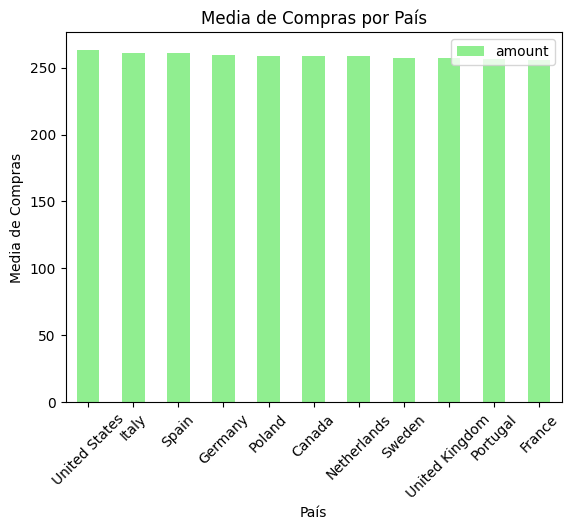

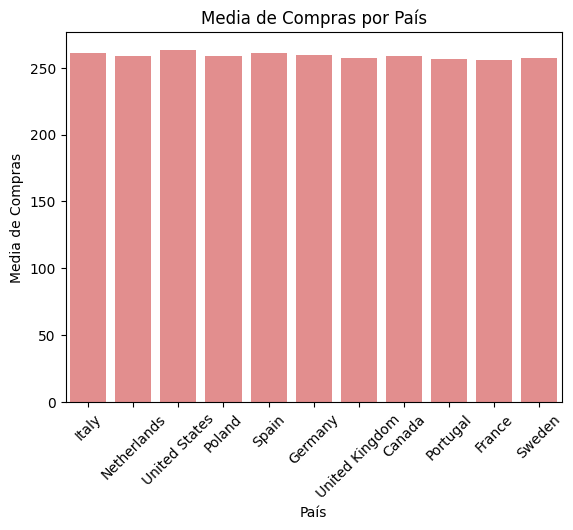

In [8]:
compres_x_pais = pd.merge(dicc_df_BBDD["transactions"], dicc_df_BBDD["users"], left_on='user_id', right_on='id')  # origen diccionario_df

#compres_x_pais.groupby('country').count()['amount'].reset_index()
#compres_x_pais.groupby('country')[['amount']].mean().reset_index()
#compres_x_pais.head(3)

# agrupo la mitjana de les compres x pais
compres_x_pais = compres_x_pais.groupby('country')[['amount']].mean().reset_index().round(2)
compres_x_pais = compres_x_pais.sort_values(by='amount', ascending=False)
#print(compres_x_pais)

plt.figure(figsize=(10,8))
#compres_x_pais.groupby('country')[['amount']].mean().reset_index().plot.bar(x='country', y='amount', color='lightgreen', rot=45)
compres_x_pais.plot.bar(x='country', y='amount', color='lightgreen', rot=45)
plt.title('Media de Compras por País')
plt.xlabel('País')
plt.ylabel('Media de Compras')
plt.show()

compres_x_pais2 = pd.merge(transactions, users, left_on='user_id', right_on='id')
#print(compres_x_pais2)
# Ordenar por amount de mayor a menor
orden = compres_x_pais2.sort_values('amount', ascending=False)['country']

#print(compres_x_pais)  # origen variables globals
plt.Figure(figsize=(10,8))
sns.barplot(
    data=compres_x_pais2,
    x='country',
    y='amount',
    color='lightcoral',
    errorbar=('ci', False),
    order=orden  # orden 
)
plt.title('Media de Compras por País')
plt.xlabel('País')
plt.ylabel('Media de Compras')
plt.xticks(rotation=45)
plt.show()



### - Dues variables categòriques.

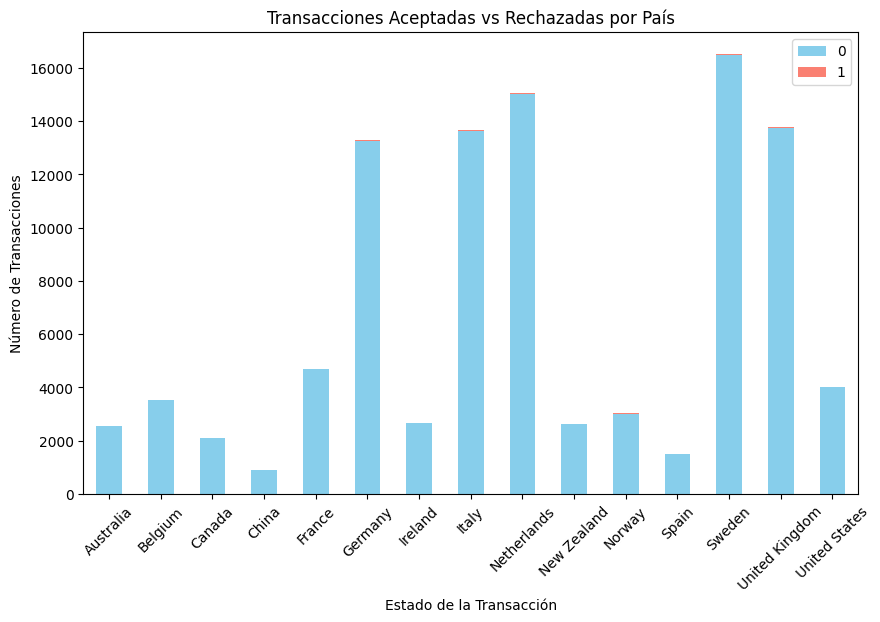

In [35]:
#pd.crosstab(dicc_df_BBDD["users"]["country"], dicc_df_BBDD["users"]["city"])  # origen diccionario_df

df_X=pd.merge(transactions, companies, left_on='business_id', right_on='company_id') 


#print(df_X.head(3))
#pd.crosstab(dicc_df_BBDD["products"]["colour"], dicc_df_BBDD["products"]["weight"]).plot(kind='bar', figsize=(10,6), color=['skyblue', 'salmon'],stacked=False)  # origen diccionario_df
#pd.crosstab(df_X["country"], df_X["declined"]).plot(kind='bar', figsize=(10,6), color=['skyblue', 'salmon'],stacked=True)

tabla_cros = pd.crosstab(df_X["country"], df_X["declined"]).reset_index()#.plot(kind='bar',x='country',stacked=True)
#print(tabla_cros)bar
tabla_cros.columns=["country","0","1"]
#print(tabla_cros)
tabla_cros.plot(kind='bar',x='country', figsize=(10,6), color=['skyblue', 'salmon'], stacked=True)

plt.title('Transacciones Aceptadas vs Rechazadas por País')
plt.xlabel('Estado de la Transacción')
plt.xticks(rotation=45)
plt.ylabel('Número de Transacciones')
plt.show()

#sns.heatmap(df_X.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")


### - Tres variables combinades.

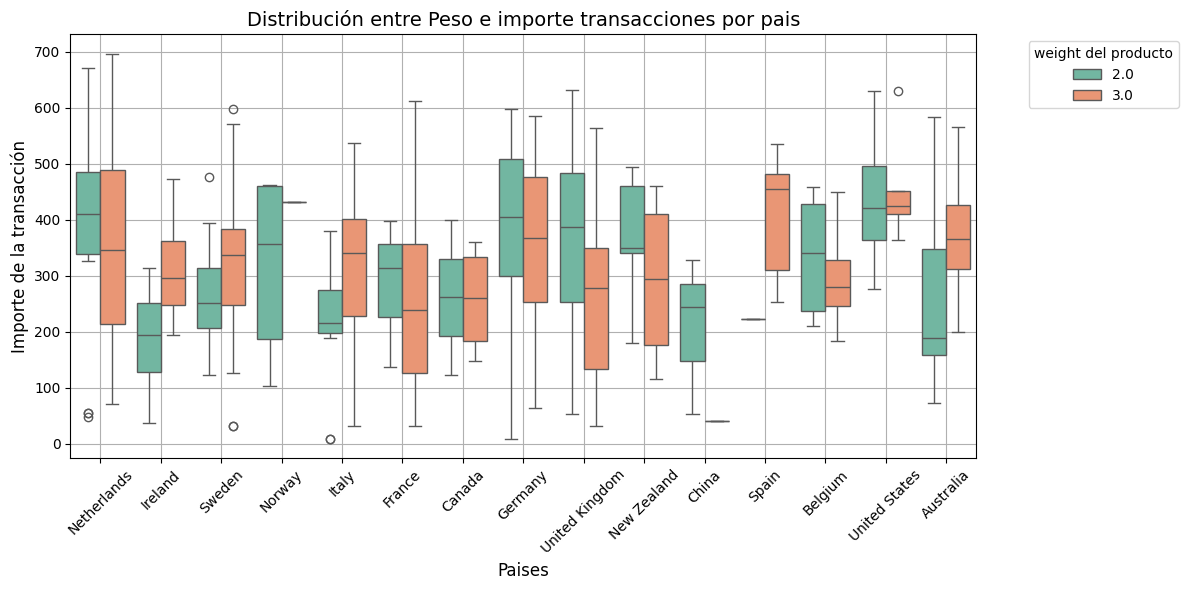

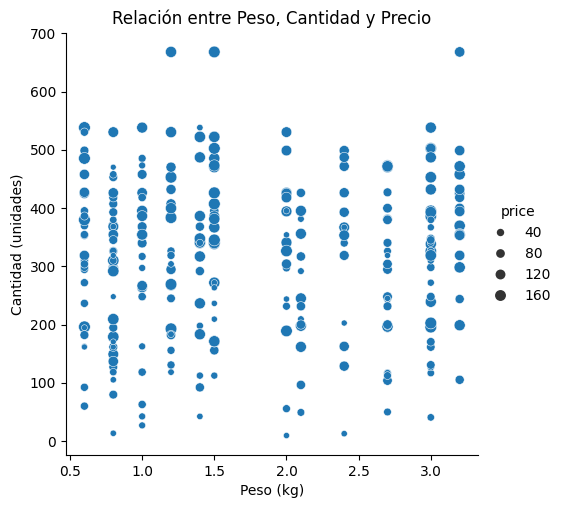

In [37]:
df_3Var=pd.merge(transactions, transaction_products, left_on='id', right_on='transaction_id')
df_3Var=pd.merge(df_3Var,products,left_on='product_id',right_on ='id')
df_3Var=pd.merge(df_3Var,companies,left_on='business_id', right_on='company_id')

# Filtrar FILAS donde weight es 2 o 3
df_3Var_boxplot=df_3Var.loc[(df_3Var['weight']==2) | (df_3Var['weight']==3)]
#df_3Var = df_3Var[df_3Var['weight'].isin([2, 3])]
df_3Var_boxplot.sort_values('country',ascending=True)
df_3Var_boxplot=df_3Var_boxplot.head(300)

# Añadir el índice con reset_index()
df_3Var = df_3Var.reset_index()

df_3Var=df_3Var.head(300)

#print(df_3Var)

# Configuración del gráfico
plt.figure(figsize=(12, 6))

# Boxplot con hue (color por 'colour')
sns.boxplot(
    data=df_3Var_boxplot,
    x='country',
    y='amount',
    hue='weight',
    palette='Set2'
)

# Títulos y etiquetas
plt.title('Distribución entre Peso e importe transacciones por pais', fontsize=14)
plt.xlabel('Paises', fontsize=12)
plt.ylabel('Importe de la transacción', fontsize=12)

# Mejorar legibilidad
plt.xticks(rotation=45)
plt.legend(title='weight del producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#lineas
plt.grid(True)
plt.show()

# grafica seaborn relplot, 3er variable=size
sns.relplot(x='weight', y='amount', data=df_3Var, size="price")
plt.title('Relación entre Peso, Cantidad y Precio')
plt.xlabel('Peso (kg)')
plt.ylabel('Cantidad (unidades)')
plt.show()

# grafica seaborn lmplot
#sns.lmplot(x='weight', y='amount', data=df_3Var, palette='Set2',row='country',legend=True)
#plt.show()



In [11]:
df_3Var_boxplot.head(3)

,id_x,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,price,colour,weight,warehouse_id,company_id,company_name,phone,email,country,website
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,180.91,#666666,3.0,WH--11,b-2458,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110\r
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,53.01,#898989,2.0,WH--21,b-2458,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110\r
8,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,180.91,#666666,3.0,WH--11,b-2390,Neque Tellus Imperdiet Corp.,09 15 42 22 11,vestibulum.ante.ipsum@aol.edu,Ireland,https://whatsapp.com/sub/cars\r


### - Crea un Pairplot.

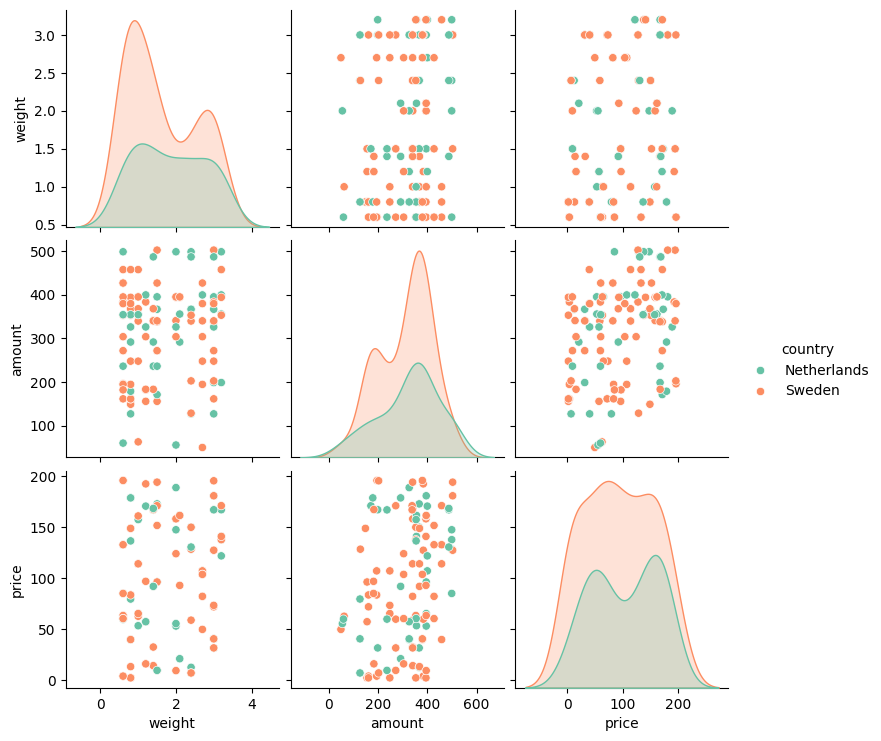

In [29]:
paises = ['Netherlands', 'Sweden']
df_filtrado = df_3Var[df_3Var['country'].isin(paises)]

#print(df.head(5))
sns.pairplot(data=df_filtrado,vars=['weight', 'amount', 'price'], hue='country', palette='Set2')
#plt.show()



# Sprint 11 - Nivell 2

## Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

<Axes: >

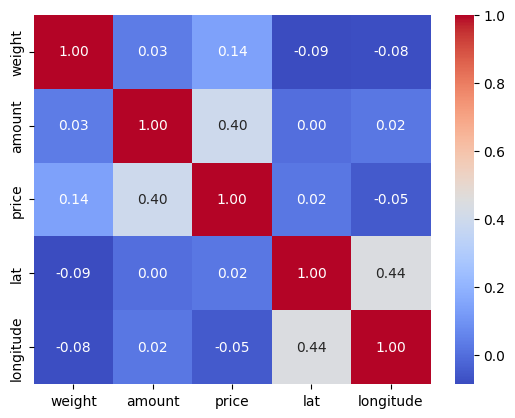

In [39]:
#df_cor=dicc_df_BBDD["products"].corr(numeric_only=True)  # origen diccionario_df

# seleccionem els camps númerics que volem  mostrar
df_cor=df_3Var[['weight', 'amount', 'price','lat','longitude']]
sns.heatmap(df_cor.corr(), annot=True, cmap='coolwarm', fmt=".2f")




# Sprint 11 - Nivell 3

## Transfereix totes les visualitzacions del Nivell 1 a Power BI utilitzant scripts de Python.

__Recorda: quan carreguis els teus dataframes a Power BI, assegura't d’incloure una columna identificadora o una combinació de columnes que garanteixi la unicitat de cada registre. Per defecte, Power BI elimina duplicats i podries perdre informació.__

### - Script per executar al PowerBI i crear tots els DATAFRAME que apareixen al arxiu

In [46]:

import mysql.connector

class MySQLConnection:
    def __init__(self, host, user, password, database):
        self.host = host
        self.user = user
        self.password = password
        self.database = database
        self.connection = None

    def connect(self):
        try:
            self.connection = mysql.connector.connect(
                host=self.host,
                user=self.user,
                password=self.password,
                database=self.database
            )
            print("Connection to MySQL Workbench established.")
        except mysql.connector.Error as err:
            print(f"Error: {err}")

    def disconnect(self):
        if self.connection:
            self.connection.close()
            print("Connection to MySQL Workbench closed.")

    def execute_query(self, query):
        cursor = self.connection.cursor()
        cursor.execute(query)
        results = cursor.fetchall()
        cursor.close()
        return results

import pandas as pd
from IPython.display import display

def cargar_tablas_en_diccionario(conexion):
    """Carga todas las tablas de la BBDD en un diccionario de DataFrames."""
    if conexion is None or not conexion.is_connected():
        print("No hay conexión activa")
        return None

    cursor = conexion.cursor()
    cursor.execute("SHOW TABLES")
    tablas = cursor.fetchall()

    dataframes = {}

    for (nombre_tabla,) in tablas:
        query = f"SELECT * FROM `{nombre_tabla}`"
        df = pd.read_sql(query, conexion)        
        dataframes[nombre_tabla] = df
        print(f"Tabla '{nombre_tabla}' cargada ({len(df)} filas)")

    cursor.close()
    return dataframes



# FEM LA CONEXIÓ
db = MySQLConnection(host='localhost', user='root', password='lluis1976', database='sprint4')
db.connect()

dicc_df_BBDD = cargar_tablas_en_diccionario(db.connection)

db.disconnect()


##################################################################################################
#### DATAFRAME -> df
#### Pestanya del poweBI anomenada -> Gràfics: 1 var nro & 2 var nro
#### Grafic -> histograma
##################################################################################################
df = dicc_df_BBDD["transactions"]["amount"].to_frame().reset_index().rename(columns={'index': 'id_unico','amount': 'media_ventas'})
print("---------------------------- DataFRame: df")
display(df)

##################################################################################################
#### DATAFRAME -> nro_praduct_sell
#### Pestanya del poweBI anomenada -> Gràfics: 1 var nro & 2 var nro
#### Grafic -> scatter
##################################################################################################
nro_praduct_sell = dicc_df_BBDD["transaction_products"].groupby("product_id").count().reset_index()
print("---------------------------- DataFRame: nro_praduct_sell")
display(nro_praduct_sell)

##################################################################################################
#### DATAFRAME -> pais
#### Pestanya del poweBI anomenada -> Gràfic: 1 var categórica & 1 var cat + 1 var nro
#### Grafic -> de barres amb plt.bar
##################################################################################################
pais = dicc_df_BBDD["users"]["country"].value_counts().reset_index()  # origen diccionario_df
print("---------------------------- DataFRame: pais")
display(pais)

##################################################################################################
#### DATAFRAME -> compres_x_pais
#### Pestanya del poweBI anomenada -> Gràfic: 1 var categórica & 1 var cat + 1 var nro
#### Grafic -> de barres amb dataset.plot.bar
##################################################################################################
compres_x_pais = pd.merge(dicc_df_BBDD["transactions"], dicc_df_BBDD["users"], left_on='user_id', right_on='id')  # origen diccionario_df
# agrupo la mitjana de les compres x pais
compres_x_pais = compres_x_pais.groupby('country')[['amount']].mean().reset_index()
compres_x_pais = compres_x_pais.sort_values(by='amount', ascending=False)
print("---------------------------- DataFRame: compres_x_pais")
display(compres_x_pais)

##################################################################################################
#### DATAFRAME -> tabla_cros
#### Pestanya del poweBI anomenada -> Grafic 2 var categóriques
#### Grafic -> de barres apilades amb dataset.plot
##################################################################################################
df_X=pd.merge(dicc_df_BBDD["transactions"], dicc_df_BBDD["companies"], left_on='business_id', right_on='company_id') 
tabla_cros = pd.crosstab(df_X["country"], df_X["declined"]).reset_index()
tabla_cros.columns=["country","0","1"]
print("---------------------------- DataFRame: tabla_cros")
display(tabla_cros)

##################################################################################################
#### DATAFRAME -> df_3Var, ens servira com a basa per treure altres dataframes
#### Pestanya del poweBI anomenada ->Gràfic 3 var. combinades
#### Grafic -> de dispersió usant sns.relplot
##################################################################################################
df_3Var=pd.merge(dicc_df_BBDD["transactions"],dicc_df_BBDD["transaction_products"], left_on='id', right_on='transaction_id')
df_3Var=pd.merge(df_3Var,dicc_df_BBDD["products"],left_on='product_id',right_on ='id')
df_3Var=pd.merge(df_3Var,dicc_df_BBDD["companies"],left_on='business_id', right_on='company_id')

# Sustituir punto por coma en amount, price y weight
for col in ['amount', 'price', 'weight']:
    if col in df_3Var.columns:
        df_3Var[col] = df_3Var[col].astype(str).str.replace('.', ',', regex=False)

# Seleccionar solo las columnas deseadas perque el PowerBiinterpretibé els decimals
df_3Var = df_3Var[['price', 'weight', 'amount','country']]

# Añadir el índice con reset_index()
df_3Var = df_3Var.reset_index()
df_3Var=df_3Var.head(300)
print("---------------------------- DataFRame: df_3Var")
display(df_3Var)


##################################################################################################
#### DATAFRAME -> df_3Var_boxplot, uso com a base df_3Var
#### Pestanya del poweBI anomenada ->Gràfic 3 var. combinades
#### Grafic -> de dispersió usant sns.boxplot
##################################################################################################
# Filtrar FILAS donde weight es 2 o 3
df_3Var_boxplot=df_3Var.loc[(df_3Var['weight']=='2,0') | (df_3Var['weight']=='3,0')]
# df_3Var_boxplot = df_3Var[df_3Var['weight'].isin(['2,0',' 3,0'])]
df_3Var_boxplot=df_3Var_boxplot.reset_index()
print("---------------------------- DataFRame: df_3Var_boxplot")
display(df_3Var_boxplot)


##################################################################################################
#### DATAFRAME -> df_filtrado_Pairplot, uso com a base df_3Var
#### Pestanya del poweBI anomenada ->Gràfic 3 var. combinades
#### Grafic -> de dispersió usant sns.boxplot
##################################################################################################
# Seleccionamos solo los paises que queremos comparar
paises = ['Netherlands', 'Sweden']
df_filtrado_Pairplot = df_3Var[df_3Var['country'].isin(paises)]
print("---------------------------- DataFRame: df_filtrado_Pairplot")
display(df_filtrado_Pairplot)

Connection to MySQL Workbench established.
Tabla 'companies' cargada (100 filas)
Tabla 'credit_card' cargada (5000 filas)
Tabla 'credit_card_status' cargada (5000 filas)
Tabla 'laptop' cargada (5 filas)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10960\3551594980.py:52: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


Tabla 'maximosminimosamoutxusuario' cargada (5000 filas)
Tabla 'products' cargada (100 filas)
Tabla 'theatersnew' cargada (1564 filas)
Tabla 'transaction_products' cargada (253391 filas)
Tabla 'transactions' cargada (100000 filas)
Tabla 'transactionsproductsuserscompanies' cargada (253391 filas)
Tabla 'users' cargada (5000 filas)
Connection to MySQL Workbench closed.
---------------------------- DataFRame: df


,id_unico,media_ventas
0,0,395.43
1,1,155.63
2,2,326.01
3,3,161.60
4,4,148.91
...,...,...
99995,99995,247.39
99996,99996,349.13
99997,99997,234.22
99998,99998,148.91


---------------------------- DataFRame: nro_praduct_sell


...

,index,price,weight,amount,country
0,0,"180,91","3,0","395,43",Netherlands
1,1,"53,01","2,0","395,43",Netherlands
2,2,"96,26","1,5","395,43",Netherlands
3,3,"65,25","1,0","395,43",Netherlands
4,4,"2,12","0,8","155,63",Sweden
...,...,...,...,...,...
295,295,"169,96","2,7","471,77",Italy
296,296,"130,59","2,4","471,77",Italy
297,297,"130,59","2,4","487,15",Netherlands
298,298,"167,15","3,0","487,15",Netherlands


---------------------------- DataFRame: df_3Var_boxplot


,level_0,index,price,weight,amount,country
0,0,0,"180,91","3,0","395,43",Netherlands
1,1,1,"53,01","2,0","395,43",Netherlands
2,8,8,"180,91","3,0","326,01",Ireland
3,16,16,"127,44","3,0","383,63",Sweden
4,32,32,"188,94","2,0","188,94",Norway
5,37,37,"65,07","3,0","298,18",Italy
6,42,42,"71,89","3,0","239,04",France
7,43,43,"167,15","3,0","239,04",France
8,45,45,"31,52","3,0","271,87",Sweden
9,48,48,"195,62","3,0","195,62",Canada


---------------------------- DataFRame: df_filtrado_Pairplot


,index,price,weight,amount,country
0,0,"180,91","3,0","395,43",Netherlands
1,1,"53,01","2,0","395,43",Netherlands
2,2,"96,26","1,5","395,43",Netherlands
3,3,"65,25","1,0","395,43",Netherlands
4,4,"2,12","0,8","155,63",Sweden
...,...,...,...,...,...
281,281,"103,73","2,7","303,97",Sweden
282,282,"15,87","1,2","303,97",Sweden
297,297,"130,59","2,4","487,15",Netherlands
298,298,"167,15","3,0","487,15",Netherlands
